In [ ]:
# 安装包
!python -m pip install joypy

山峦图（Ridge plot）形似山的脊背⛰，因此得名。而“Joy Plot”这个名称则源于Joy Division 乐队在其专辑封面上使用了这种图形。

这种图形沿 x 轴展示多个山脊状的曲线，通常称为概率密度或核密度分布曲线。图中每个峰的高度表示其对应值的发生概率，峰值越高，意味着该数值出现的频率越高。

山峦图适用于比较一个或多个变量在不同组别中的分布情况，例如历年各月的气温、不同时间段的退单量或NBA历年的三分球命中率等。

In [122]:
df = pd.read_csv('NetflixOriginals.csv', header=0)

# 打印列名
print(df.columns)

Index(['Title', 'Genre', 'GenreLabels', 'Premiere', 'Seasons', 'SeasonsParsed',
       'EpisodesParsed', 'Length', 'MinLength', 'MaxLength', 'Status',
       'Active', 'Table', 'Language'],
      dtype='object')


### joyplot函数主要参数介绍：- **data**: 可以是数据帧（DataFrame）、系列（Series）或嵌套集合，通常使用 pandas 的 DataFrame 作为数据输入。- **ax**: Matplotlib 的 Axes 对象，如果未指定，默认为 None。- **column**: 字符串或序列类型。若提供该参数，将用于筛选数据的列子集。- **by**: 选择项。定义要根据哪个特征划分不同数据组。本例中使用 “Language” 字段。- **grid**: 布尔值，默认为 True，控制是否在图表上显示网格线。- **title**: 图表的标题文本。- **alpha**: 控制图形透明度的参数。- **xlabels, ylabels**: 可以是布尔值或列表，默认值为 True，用于控制轴标签显示与否。- **xlabelsize**: 整数类型，默认为 None。如果指定，则调整 X 轴标签的字体大小。- **xrot**: 浮点数，默认为 None，决定 X 轴标签旋转的角度。- **ylabelsize**: 整数类型，默认为 None。如果指定，则调整 Y 轴标签的字体大小。- **yrot**: 浮点数，默认为 None，决定 Y 轴标签旋转的角度。- **figsize**: 元组类型，指定绘制图形的尺寸（单位为英寸）。- **color**: 图形使用的颜色，可以是字符串或其他 Matplotlib 可识别的颜色格式，通常提供颜色列表。- **kwds**: 其他绘图时的关键字参数，这些参数会传递给 `hist`、`kde` 等函数。

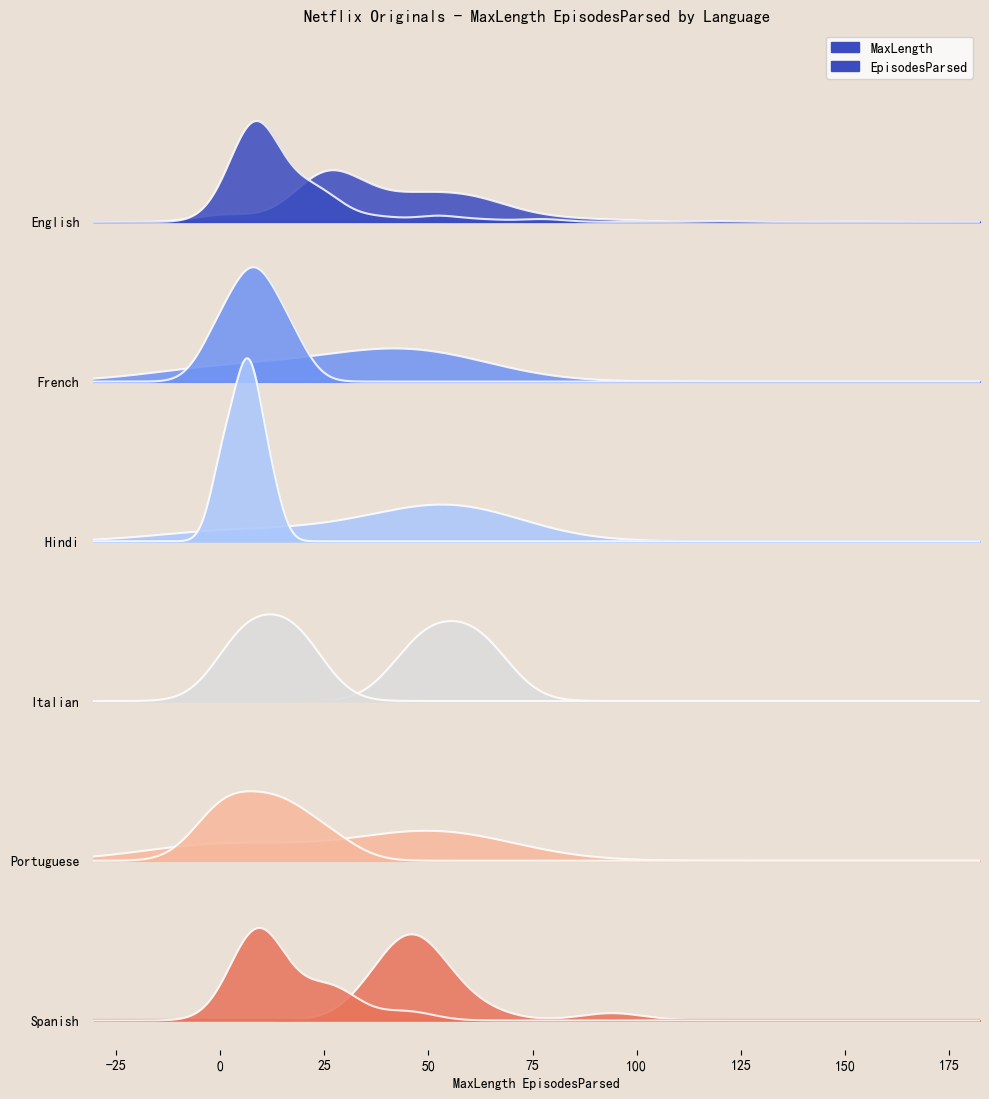

In [124]:
# 导入所需库
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from joypy import joyplot

# 数据预处理函数
def prepare_data(filepath, language_list):
    """
    读取CSV文件并筛选特定语言的数据
    参数:
    - filepath: CSV文件路径
    - language_list: 需要保留的语言列表
    返回:
    - 筛选后的数据框
    """
    df = pd.read_csv(filepath, header=0)  # 读取CSV文件
    # 筛选所需语言并选择特定列
    df_filtered = df[df['Language'].isin(language_list)][['Title', 'EpisodesParsed', 'MaxLength', 'Language']]
    return df_filtered

# 绘制山脊图的函数
def plot_ridge(df_filtered, colormap_name="coolwarm", save_path=None):
    """
    绘制山脊图 (JoyPlot) 并进行美化处理
    参数:
    - df_filtered: 筛选后的数据框
    - colormap_name: Seaborn色盘名称，默认使用 'coolwarm'
    - save_path: 保存图片的路径，若为None，则不保存
    """
    # 创建山脊图，设置图形参数
    fig, ax = joyplot(df_filtered, 
                      by='Language', 
                      column=['MaxLength', 'EpisodesParsed'], 
                      figsize=(10, 12),
                      linecolor="white",  # 线条颜色
                        #   as_cmap=True 适合以下场景：
                        # 热图（heatmap）：根据数值大小绘制颜色渐变。
                        # 等高线图（contour plot）：根据数据值变化绘制平滑的颜色渐变。
                        # 山脊图（joyplot）：展示连续变量分布时，使用颜色渐变表示密度。
                      colormap=sns.color_palette(colormap_name, as_cmap=True),  # 颜色映射
                      background='#eae0d5', # 背景颜色
                      legend=True, # 是否显示图例
                      alpha=0.86) # 设置透明度。

    # 美化图形
    fig.set_facecolor('#eae0d5')  # 设置背景颜色
    plt.xlabel('MaxLength EpisodesParsed')  # 设置x轴标签
    plt.title("Netflix Originals - MaxLength EpisodesParsed by Language")  # 设置标题
    plt.subplots_adjust(top=0.95, bottom=0.1)  # 调整图形边距

    # 保存图片（如果提供保存路径）
    if save_path:
        plt.savefig(save_path, dpi=300)  # 保存图像为高清格式

# 主函数
def main():
    # 设定文件路径和语言列表
    csv_filepath = 'NetflixOriginals.csv'  # CSV文件路径
    languages = ['English', 'Hindi', 'Spanish', 'French', 'Italian', 'Portuguese']  # 选择的语言

    # 数据预处理
    df_filtered = prepare_data(csv_filepath, languages)

    # 绘制图形并保存
    #  colormap_name 允许动态地选择不同的颜色映射方案，例如：
    # "coolwarm"：从冷色到暖色的渐变。
    # "viridis"：适合色盲用户的渐变色。
    # "Blues"：单一蓝色调的渐变。
    plot_ridge(df_filtered, colormap_name="coolwarm", save_path='joyplot_MaxLength.png')

# 执行主函数
if __name__ == "__main__":
    main()


In [126]:
import pandas as pd
from matplotlib import cm

# 读取CSV文件
df = pd.read_csv('daily-min-temperatures.csv', delimiter=',') 

# 转换日期列为datetime格式
df['Date'] = pd.to_datetime(df['Date'])

# 提取年、月、日以及温度
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['temp'] = df['Temp']

# 选择需要的列
df_final = df[['year', 'month', 'day', 'temp']]

# 显示结果
print(df_final)

      year  month  day  temp
0     1981      1    1  20.7
1     1981      1    2  17.9
2     1981      1    3  18.8
3     1981      1    4  14.6
4     1981      1    5  15.8
...    ...    ...  ...   ...
3645  1990     12   27  14.0
3646  1990     12   28  13.6
3647  1990     12   29  13.5
3648  1990     12   30  15.7
3649  1990     12   31  13.0

[3650 rows x 4 columns]


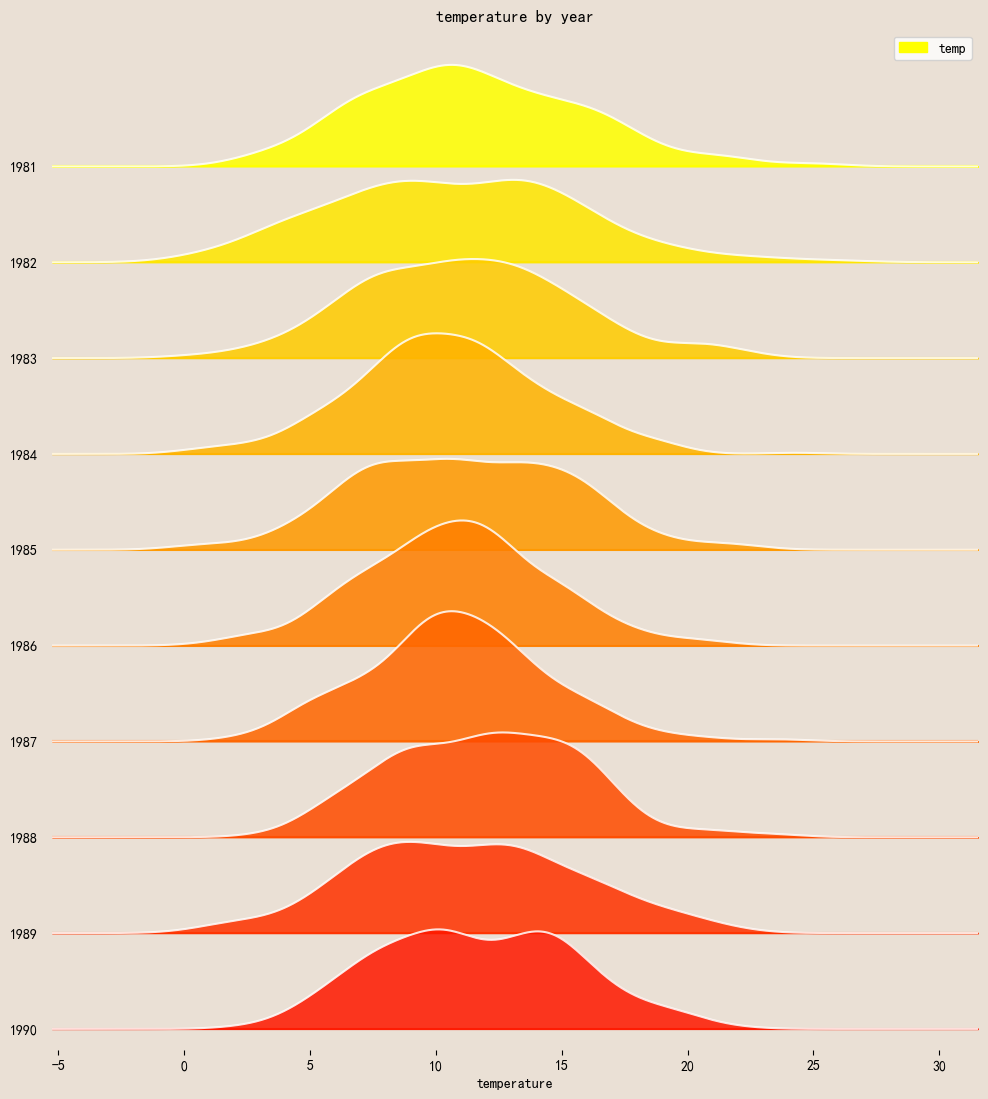

In [128]:
fig, ax = joyplot(df_final, 
                  by='year', 
                  column='temp', 
                  figsize=(10, 12),
                  linecolor="white",  # 线条颜色
                  colormap=cm.autumn_r,  # 颜色映射
                  background='#eae0d5', # 背景颜色
                  legend=True, # 是否显示图例
                  alpha=0.86) # 设置透明度。

# 美化图形
fig.set_facecolor('#eae0d5')  # 设置背景颜色
plt.xlabel('temperature')  # 设置x轴标签
plt.title("temperature by year")  # 设置标题
plt.subplots_adjust(top=0.95, bottom=0.1)  # 调整图形边距

# 保存图片
plt.savefig('joyploy_temp.png', dpi=300)  # 保存图像为高清格式

In [130]:
import pandas as pd

df = pd.read_csv('iris.csv') # 使用鸢尾花数据集

print(f"特征：{list(df.columns)[:-1]}")
print(f"标签：{list(df.columns)[-1]}")


特征：['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
标签：variety


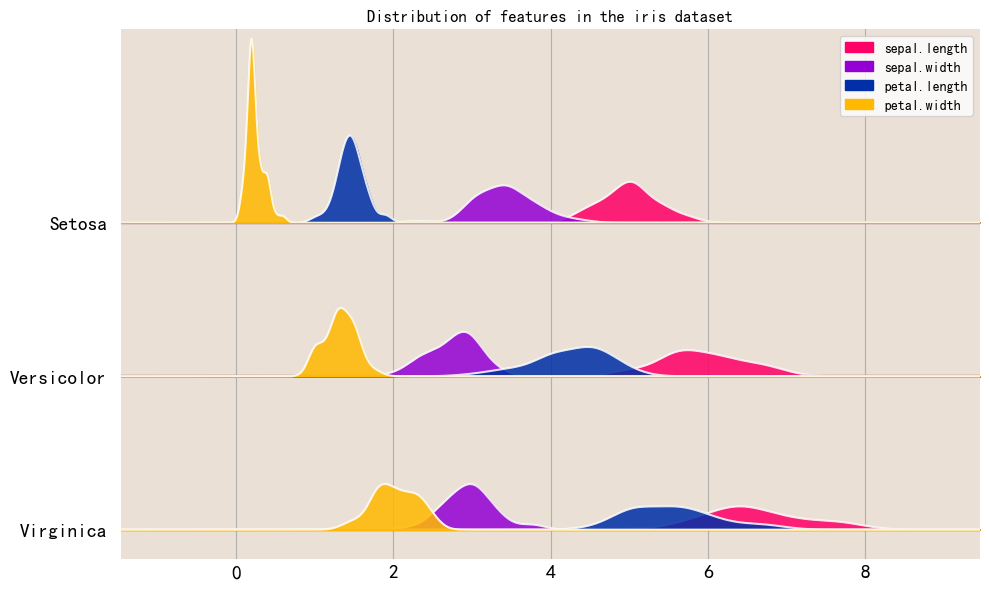

In [132]:
cols = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']

fig, ax = joyplot(data=df,
                  by='variety', 
                  column=cols,
                  figsize=(10, 6),
                  xlabelsize=14,
                  ylabelsize=14,
                  grid=True,
                  hist=False,
                  linecolor="white",  # 线条颜色
                  # colormap=cm.autumn_r,  # 颜色映射
                  color=['#FF0066', '#9400D3','#002FA7', '#FFB900'],
                  background='#eae0d5', # 背景颜色
                  legend=True, # 是否显示图例
                  title='Distribution of features in the iris dataset',
                  alpha=0.86) # 设置透明度。

fig.savefig("joyplot_iris.png", dpi=300)

plt.show()